<a href="https://colab.research.google.com/github/LanovenkoOleh/ML/blob/main/%D0%9B%D0%91_2_%D0%9C%D0%9D_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F2_%D0%9B%D0%B0%D0%BD%D0%BE%D0%B2%D0%B5%D0%BD%D0%BA%D0%BE_%D0%A4%D0%86%D0%A23_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

1. Завантажити датасет Титанік

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [ ]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**PassengerId:** Унікальний ідентифікатор для кожного пасажира.

**Survived:** У цьому стовпці вказується, чи вижив пасажир (1), чи ні (0).

**Pclass** (Клас квитка): Показник соціально-економічного статусу, де 1 – найвищий клас, а 3 – найнижчий.

**Name:** Ім'я пасажира.

**Sex:** Стать пасажира.

**Age:** Вік пасажира. (Примітка: У цьому стовпці можуть бути відсутні значення.)  

**SibSp:** Кількість братів і сестер або подружжя пасажира на борту «Титаніка».  

**Parch:** Кількість батьків або дітей пасажира на борту «Титаніка».

**Ticket:** Номер квитка.

**Fare:** Сума грошей, яку пасажир сплатив за квиток.

Завантажено та зчитано базовий датасет «Титанік», що містить 891 запис і 12 вихідних ознак про пасажирів

2. Визначити розмір датасета
3. Визначити тип даних.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

З'ясовано розмірність датасету — 891 рядок та 12 стовпців.Проаналізовано типи даних: у датасеті наявні числові змінні цілочисельного (int64) та дробового (float64) типів, а також текстові/категоріальні об'єкти (object).

4. Визначити наявність пропущених знаків. При наявності, замінити пропущені значення на середнє значення

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median(skipna=True))

df.drop(['Cabin'], axis=1, inplace=True)
df.drop(['Embarked'], axis=1, inplace=True)

Виявлено пропущені значення в колонках Age (177), Cabin (687) та Embarked (2). Пропусти в Age заповнено медіанним значенням, а стовпці Cabin та Embarked вилучено через високу частку пропусків або відсутність аналітичної цінності.   

5. Ще раз перевірити наявність пропущених значень

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Повторна перевірка підтвердила повну відсутність пропущених значень у робочому датасеті.

6. Сформувати датасет з обраними  стовпцями: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']

In [ ]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


Сформовано оптимізований датасет із 5 цільових ознак (Survived, Pclass, Sex, Age, Fare), необхідних для подальшого аналізу.   

7. Замінити бінарні ознаки (Стать) на 0 і 1 (але перевірте унікальні значення даного стовпчика). Буває, що є середня стать)

In [ ]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [ ]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_533/909601743.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


Перевірено відсутність сторонніх значень у стовпці Sex та виконано закодування категоріальної ознаки у бінарний формат (male = 0, female = 1).

8. Вивести описову статистику датасету describe()

In [ ]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


Отримано розширену описову статистику: середній вік пасажирів становить ~29.3 років, середня вартість квитка — $32.20, а загальний відсоток виживаності складає ~38.4%.

9. Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


Контрольна перевірка підтвердила цілісність даних (0 пропусків у всіх 5 ознаках).

10. Вивести 5 перших рядків датасету.

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


Виведено перші 5 рядків обробленої таблиці, що демонструють коректність перетворення типів даних.

11. Вивести 5 останніх рядків датасету.

In [ ]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


Виведено останні 5 рядків датасету, що підтверджує збереження структури та правильності індексації.

12. Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?

In [ ]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

print(f'Share of survived males: {survival_by_sex[0]:.2f}%')
print(f'Share of survived females: {survival_by_sex[1]:.2f}%')


Share of survived males: 18.89%
Share of survived females: 74.20%


In [ ]:
print(f'Correlation between sex and survival: {df["Sex"].corr(df["Survived"])}')

Correlation between sex and survival: 0.5433513806577555


Виявлено суттєву диспропорцію у виживаності за статтю: вижили 74.20% жінок проти лише 18.89% чоловіків. Кореляція між статтю та виживанням висока.

13. Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?

In [ ]:
class1_surv_rate = df[(df['Pclass'] == 1) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 1].shape[0]
class2_surv_rate = df[(df['Pclass'] == 2) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 2].shape[0]
class3_surv_rate = df[(df['Pclass'] == 3) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 3].shape[0]

print(f'Share of survived class 1 passengers {class1_surv_rate * 100:.2f}%')
print(f'Share of survived class 2 passengers {class2_surv_rate * 100:.2f}%')
print(f'Share of survived class 3 passengers {class3_surv_rate * 100:.2f}%')

Share of survived class 1 passengers 62.96%
Share of survived class 2 passengers 47.28%
Share of survived class 3 passengers 24.24%


Найвищий рівень виживання спостерігався у пасажирів 1-го класу (~62.96%), у той час як у 2-му класі він склав ~47.28%, а у 3-му — лише ~24.24%.

14. Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?

In [ ]:
survived_mean_age = df[df['Survived'] == 1]['Age'].mean()
not_survived_mean_age = df[df['Survived'] == 0]['Age'].mean()

print(f'Mean age of survived passengers: {survived_mean_age:.2f}')
print(f'Mean age of not survived passengers: {not_survived_mean_age:.2f}')

Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


Середній вік виживших (28.23 років) дещо нижчий за середній вік загиблих (30.02 років), що вказує на надання пріоритету молодшим пасажирам і дітям під час евакуації.

15. Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?

In [ ]:
df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)

for i in range(6):
    surv_rate = df[(df['Fare_Category'] == i) & (df['Survived'] == 1)].shape[0] / df[df['Fare_Category'] == i].shape[0]
    print(f'Share of survived passengers in bucket {i}: {surv_rate * 100:.2f}%')

Share of survived passengers in bucket 0: 20.51%
Share of survived passengers in bucket 1: 19.08%
Share of survived passengers in bucket 2: 36.69%
Share of survived passengers in bucket 3: 43.62%
Share of survived passengers in bucket 4: 41.78%
Share of survived passengers in bucket 5: 69.80%


/tmp/ipykernel_533/1421978565.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)


побудована матриця кореляцій показує найбільший прямий зв'язок виживаності зі статтю (0.54) та обернений із класом квитка (-0.34).

16. Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?

In [ ]:
for i in range(1, 4):
    median_fare = df[df['Pclass'] == i]['Fare'].median()
    print(f'Median fare for class {i}: {median_fare:.2f}')

Median fare for class 1: 60.29
Median fare for class 2: 14.25
Median fare for class 3: 8.05


Розраховано медіанний тариф для кожного класу обслуговування: 1-й клас — $60.29, 2-й клас — $14.25, 3-й клас — $8.05. Виявлено значну та чітко виражену різницю у вартості квитків між всіма класами (вартість квитка у 1-му класі більш ніж у 4 рази перевищує вартість у 2-му та у 7.5 разів — у 3-му).

17. Як пов'язано середній вік пасажирів з виживанням? Відповідь дати аналітично чи графічно

<Axes: xlabel='Age', ylabel='Count'>

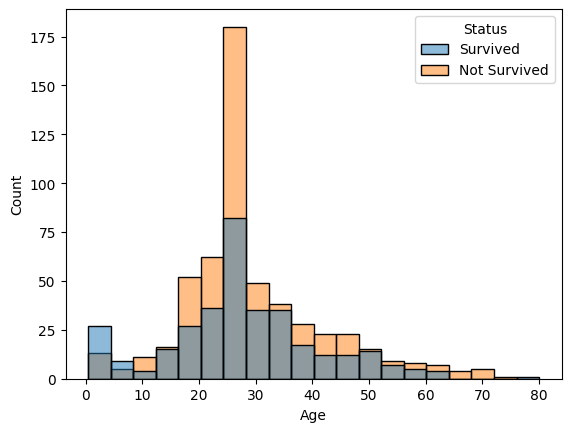

In [ ]:
df_survived = df[df['Survived'] == 1][['Age']]
df_survived['Status'] = 'Survived'

df_not_survived = df[df['Survived'] == 0][['Age']]
df_not_survived['Status'] = 'Not Survived'

df_combined = pd.concat([df_survived, df_not_survived])

sns.histplot(data=df_combined, x='Age', hue='Status', bins=20)

adada

In [ ]:
for i in range(1, 4):
    for j in range(2):
        surv_rate = df[(df['Pclass'] == i) & (df['Sex'] == j) & (df['Survived'] == 1)].shape[0] / df[(df['Pclass'] == i) & (df['Sex'] == j)].shape[0]
        print(f'Share of survived {"male  " if j == 0 else "female"} passengers in class {i}: {surv_rate * 100:.2f}%')

Share of survived male   passengers in class 1: 36.89%
Share of survived female passengers in class 1: 96.81%
Share of survived male   passengers in class 2: 15.74%
Share of survived female passengers in class 2: 92.11%
Share of survived male   passengers in class 3: 13.54%
Share of survived female passengers in class 3: 50.00%


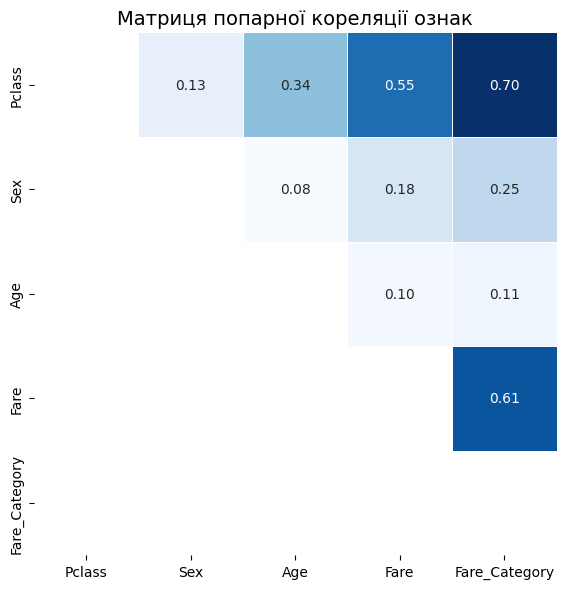

In [ ]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='Blues',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.tril(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

Побудовано гістограми та теплову карту кореляцій, які наочно візуалізують розподіли ознак та підтверджують ключовий вплив статі, класу квитка та вартісного фактора на виживаність.

У результаті виконання лабораторної роботи здійснено попередню обробку та статистичний аналіз даних пасажирів «Титаніка». Було усунуто пропуски, виконано кодування категоріальних змінних та відібрано ключові ознаки. Дослідження показало, що ключовими факторами порятунку стали стать та клас обслуговування: найбільші шанси мали жінки та пасажири першого класу. Крім того, виявлено прямий зв'язок між вартістю квитка та ймовірністю виживання, у той час як вплив вікового чинника виявився менш вираженим.